In [112]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [113]:
import pandas as pd

df = pd.read_csv(
    r"C:\\Users\\KIIT0001\\Desktop\\Scouting_System Project\\data\\processed\\players_data-2025_2026.csv"
)

In [114]:
df = df.drop_duplicates(
    subset=["Player"]
)

df = df.reset_index(drop=True)

print(df.shape)

(2687, 102)


In [115]:
FEATURES = [

    "Gls",
    "Ast",
    "Sh",
    "SoT",
    "TklW",
    "Int",
    "Crs",
    "PPM"

]

FEATURES = [
    col
    for col in FEATURES
    if col in df.columns
]

print(FEATURES)

['Gls', 'Ast', 'Sh', 'SoT', 'TklW', 'Int', 'Crs', 'PPM']


In [116]:
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(
    df[FEATURES]
)

scaled_features.shape

(2687, 8)

In [117]:
similarity_matrix = cosine_similarity(
    scaled_features
)

similarity_matrix.shape

(2687, 2687)

In [118]:
def get_similar_players(
    player_name,
    top_n=10
):

    player_index = df[
        df["Player"] == player_name
    ].index[0]

    scores = list(
        enumerate(
            similarity_matrix[player_index]
        )
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    results = []

    for idx, score in scores[1:top_n+1]:

        results.append({

            "Player":
            df.iloc[idx]["Player"],

            "Position":
            df.iloc[idx]["Pos"],

            "Squad":
            df.iloc[idx]["Squad"],

            "Similarity":
            round(score * 100, 2)

        })

    return pd.DataFrame(results)

In [119]:
get_similar_players(
    "Declan Rice"
)

,Player,Position,Squad,Similarity
0,Romain Perraud,DF,Lille,99.49
1,Matty Cash,DF,Aston Villa,99.42
2,Mathias Jensen,MF,Brentford,98.96
3,Nicola Zalewski,MF,Atalanta,98.72
4,Jan-Niklas Beste,MF,Freiburg,98.58
5,Quentin Merlin,"DF,MF",Rennes,98.57
6,Ísak Jóhannesson,MF,Köln,98.50
7,Reece James,"DF,MF",Chelsea,98.42
8,Angelo Stiller,MF,Stuttgart,98.32
9,Davide Zappacosta,MF,Atalanta,98.30


In [120]:
def find_young_alternatives(
    player_name,
    max_age=24,
    top_n=10
):

    player_index = df[
        df["Player"] == player_name
    ].index[0]

    scores = list(
        enumerate(
            similarity_matrix[player_index]
        )
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    results = []

    for idx, score in scores:

        if idx == player_index:
            continue

        if df.iloc[idx]["Age"] > max_age:
            continue

        results.append({

            "Player":
            df.iloc[idx]["Player"],

            "Nation":
            df.iloc[idx]["Nation"],

            "Age":
            df.iloc[idx]["Age"],

            "Position":
            df.iloc[idx]["Pos"],

            "Similarity":
            round(score * 100, 2)

        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

In [121]:
find_young_alternatives(
    "Kylian Mbappé"
)

,Player,Nation,Age,Position,Similarity
0,Folarin Balogun,us USA,24.0,FW,98.69
1,Kieron Bowie,sct SCO,22.0,FW,97.48
2,Roberto Férnandez,es ESP,23.0,FW,97.25
3,Dženan Pejčinović,de GER,20.0,FW,96.72
4,Mateo Pellegrino,ar ARG,24.0,FW,96.66
5,Andreas Hountondji,bj BEN,23.0,FW,96.38
6,Benjamin Šeško,si SVN,22.0,FW,96.35
7,Lorenzo Colombo,it ITA,23.0,FW,96.32
8,Carlos Espí,es ESP,20.0,FW,96.19
9,Said El Mala,de GER,18.0,"FW,MF",96.10


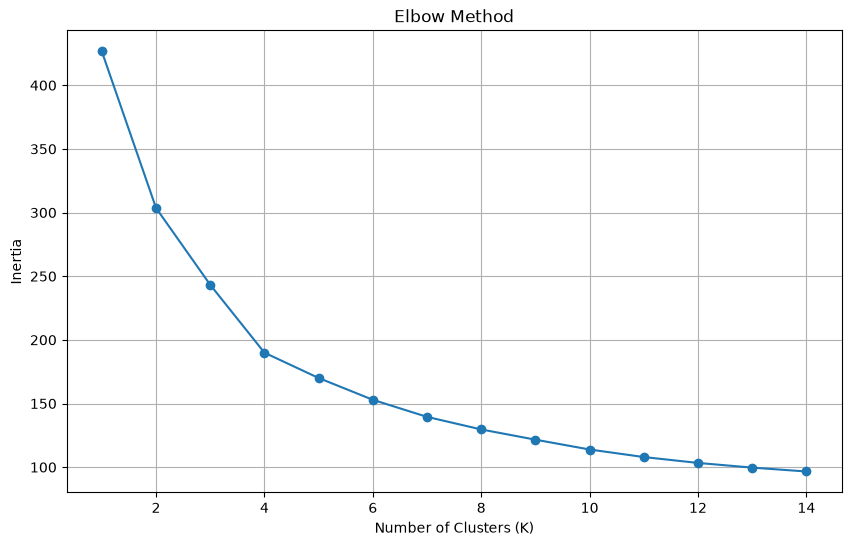

In [122]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_RANGE = range(1, 15)

for k in K_RANGE:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(10,6))

plt.plot(
    K_RANGE,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method"
)

plt.grid(True)

plt.show()

In [123]:
from sklearn.cluster import KMeans

OPTIMAL_K = 4

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

In [124]:
df["Cluster"].value_counts()

Cluster
2    1015
1     687
0     662
3     323
Name: count, dtype: int64

In [125]:
df["Cluster"].value_counts()

Cluster
2    1015
1     687
0     662
3     323
Name: count, dtype: int64

In [126]:
cluster_profiles = df.groupby(
    "Cluster"
)[FEATURES].mean()

cluster_profiles

,Gls,Ast,Sh,SoT,TklW,Int,Crs,PPM
Cluster,,,,,,,,
0,0.761329,0.646526,7.061934,2.354985,5.758308,4.654079,8.620846,2.012613
1,1.423581,1.714702,18.656477,5.403202,28.433770,26.590975,40.484716,1.325429
2,0.598030,0.379310,6.825616,2.220690,4.935961,3.731034,9.041379,0.824236
3,7.578947,3.739938,55.523220,21.588235,14.650155,9.585139,52.842105,1.513684


In [127]:
pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_features
)

df["PCA1"] = pca_result[:,0]
df["PCA2"] = pca_result[:,1]

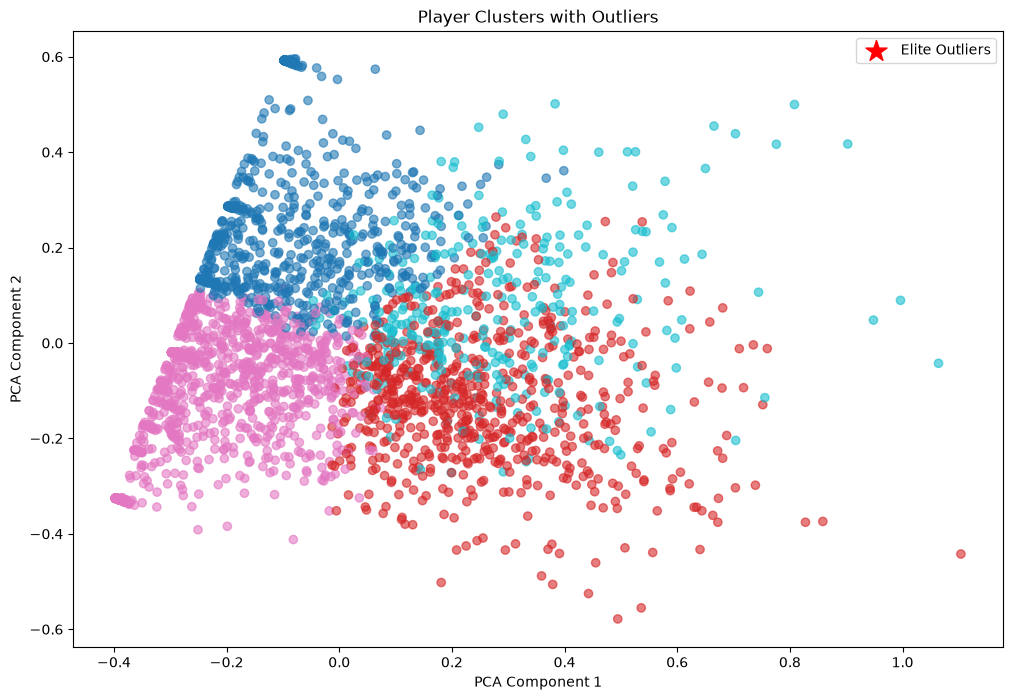

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Normal players
normal_players = df[df["Cluster"] != 7]

plt.scatter(
    normal_players["PCA1"],
    normal_players["PCA2"],
    c=normal_players["Cluster"],
    cmap="tab10",
    alpha=0.6
)

# Outliers
outliers = df[df["Cluster"] == 7]

plt.scatter(
    outliers["PCA1"],
    outliers["PCA2"],
    marker="*",
    s=250,
    color="red",
    label="Elite Outliers"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "Player Clusters with Outliers"
)

plt.legend()

plt.show()

In [129]:
print(
    df[df["Cluster"] == 7]["Player"].tolist()
)

[]


In [130]:
for _, row in outliers.iterrows():

    plt.annotate(
        row["Player"],
        (row["PCA1"], row["PCA2"]),
        fontsize=8
    )

In [131]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

df["Outlier"] = iso.fit_predict(
    scaled_features
)

In [132]:
df[
    df["Outlier"] == -1
][[
    "Player",
    "Pos"
]]

,Player,Pos
108,Elliot Anderson,MF
128,Antony,"MF,FW"
235,Christoph Baumgartner,MF
346,Jarrod Bowen,"MF,FW"
373,Ante Budimir,FW
...,...,...
2597,Ollie Watkins,FW
2611,Neco Williams,DF
2616,Harry Wilson,MF
2633,Lamine Yamal,"MF,FW"


In [133]:
cluster_df = df[
    df["Outlier"] != -1
].copy()

In [134]:
cluster_scaled = scaled_features[
    df["Outlier"] != -1
]

In [135]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(
    cluster_scaled
)

In [136]:
df["Cluster"] = -1

df.loc[
    cluster_df.index,
    "Cluster"
] = cluster_df["Cluster"]

df.loc[
    df["Outlier"] == -1,
    "Cluster"
] = 7

In [137]:
top_players = df.nlargest(
    30,
    "G+A"
)

In [138]:
def show_cluster(
    player_name
):

    cluster = df.loc[
        df["Player"] == player_name,
        "Cluster"
    ].values[0]

    return df[
        df["Cluster"] == cluster
    ][[
        "Player",
        "Pos",
        "Squad",
        "Age"
    ]]

In [139]:
show_cluster(
    "Declan Rice"
)

,Player,Pos,Squad,Age
9,Laurent Abergel,MF,Lorient,32.0
13,Abdel Abqar,DF,Getafe,26.0
23,Tyler Adams,MF,Bournemouth,26.0
34,Michel Aebischer,MF,Pisa,28.0
35,David Affengruber,DF,Elche,24.0
...,...,...,...,...
2670,Cedric Zesiger,DF,Augsburg,27.0
2680,Nadir Zortea,DF,Bologna,26.0
2681,Yanis Zouaoui,"DF,MF",Le Havre,27.0
2682,Igor Zubeldia,DF,Real Sociedad,28.0


In [140]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=FEATURES
)

pca_loadings.sort_values(
    "PC1",
    ascending=False
)

,PC1,PC2
TklW,0.579872,-0.283867
Int,0.457708,-0.250327
Sh,0.355901,0.018391
PPM,0.299836,0.917526
Crs,0.291127,-0.096650
SoT,0.273526,0.044202
Ast,0.224566,0.021082
Gls,0.166385,0.053148


In [141]:
pca_loadings.sort_values(
    "PC2",
    ascending=False
)

,PC1,PC2
PPM,0.299836,0.917526
Gls,0.166385,0.053148
SoT,0.273526,0.044202
Ast,0.224566,0.021082
Sh,0.355901,0.018391
Crs,0.291127,-0.096650
Int,0.457708,-0.250327
TklW,0.579872,-0.283867


In [142]:
import plotly.graph_objects as go

In [143]:
import plotly.graph_objects as go

RADAR_FEATURES = FEATURES

def compare_players(player1, player2):

    p1 = scaled_df[
        scaled_df["Player"] == player1
    ].iloc[0]

    p2 = scaled_df[
        scaled_df["Player"] == player2
    ].iloc[0]

    categories = RADAR_FEATURES + [RADAR_FEATURES[0]]

    values1 = [
        p1[f]
        for f in RADAR_FEATURES
    ]

    values2 = [
        p2[f]
        for f in RADAR_FEATURES
    ]

    values1 += [values1[0]]
    values2 += [values2[0]]

    fig = go.Figure()

    fig.add_trace(
        go.Scatterpolar(
            r=values1,
            theta=categories,
            fill="toself",
            name=player1
        )
    )

    fig.add_trace(
        go.Scatterpolar(
            r=values2,
            theta=categories,
            fill="toself",
            name=player2
        )
    )

    fig.update_layout(
        title=f"{player1} vs {player2}",
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0,1]
            )
        ),
        showlegend=True,
        width=800,
        height=700
    )

    fig.show()

In [144]:
scaled_df = pd.DataFrame(
    scaled_features,
    columns=FEATURES
)

scaled_df["Player"] = df["Player"]
scaled_df["Pos"] = df["Pos"]
scaled_df["Squad"] = df["Squad"]

In [145]:
compare_players(
    "Kylian Mbappé",
    "Robert Lewandowski"
)

In [146]:
percentile_df = df.copy()

for feature in FEATURES:

    percentile_df[f"{feature}_pct"] = (
        percentile_df[feature]
        .rank(pct=True)
        * 100
    )

In [147]:
def generate_scouting_report(player_name):

    player = percentile_df[
        percentile_df["Player"] == player_name
    ].iloc[0]

    print("=" * 50)
    print(f"PLAYER: {player['Player']}")
    print(f"CLUB: {player['Squad']}")
    print(f"POSITION: {player['Pos']}")
    print("=" * 50)

    for feature in FEATURES:

        pct = round(
            player[f"{feature}_pct"],
            1
        )

        print(
            f"{feature}: {pct} percentile"
        )

In [148]:
generate_scouting_report("Lamine Yamal")

PLAYER: Lamine Yamal
CLUB: Barcelona
POSITION: MF,FW
Gls: 99.6 percentile
Ast: 99.8 percentile
Sh: 99.8 percentile
SoT: 99.4 percentile
TklW: 76.3 percentile
Int: 56.7 percentile
Crs: 91.6 percentile
PPM: 96.0 percentile


In [149]:
cluster_profiles

,Gls,Ast,Sh,SoT,TklW,Int,Crs,PPM
Cluster,,,,,,,,
0,0.761329,0.646526,7.061934,2.354985,5.758308,4.654079,8.620846,2.012613
1,1.423581,1.714702,18.656477,5.403202,28.433770,26.590975,40.484716,1.325429
2,0.598030,0.379310,6.825616,2.220690,4.935961,3.731034,9.041379,0.824236
3,7.578947,3.739938,55.523220,21.588235,14.650155,9.585139,52.842105,1.513684


In [150]:
CLUSTER_NAMES = {

    0: "Average Professionals",

    1: "Defense Specialists",

    2: "Fringe Players",

    3: "Great Attackers",

    7: "Elite Outliers"

}

In [151]:
df["Cluster"].value_counts()

df[
    df["Cluster"] == 7
][["Player"]].head(30)

,Player
108,Elliot Anderson
128,Antony
235,Christoph Baumgartner
346,Jarrod Bowen
373,Ante Budimir
415,Dominic Calvert-Lewin
494,Ilyas Chaira
506,Rayan Cherki
526,Jonathan Clauss
564,Vladimír Coufal


In [152]:
df["Outlier"].value_counts()

Outlier
 1    2606
-1      81
Name: count, dtype: int64

In [153]:
print(df["Cluster"].unique())

[3 0 2 1 7]


In [154]:
df["Cluster"].unique()

array([3, 0, 2, 1, 7])

In [155]:
df["Outlier"].value_counts()

Outlier
 1    2606
-1      81
Name: count, dtype: int64

In [156]:
df[
    df["Outlier"] == -1
][[
    "Player",
    "Cluster"
]]

,Player,Cluster
108,Elliot Anderson,7
128,Antony,7
235,Christoph Baumgartner,7
346,Jarrod Bowen,7
373,Ante Budimir,7
...,...,...
2597,Ollie Watkins,7
2611,Neco Williams,7
2616,Harry Wilson,7
2633,Lamine Yamal,7


In [157]:
df["Archetype"] = (
    df["Cluster"]
    .map(CLUSTER_NAMES)
)

In [158]:
df[
    ["Player","Archetype"]
].head()

,Player,Archetype
0,Brenden Aaronson,Great Attackers
1,Jerome Abbey,Average Professionals
2,Zach Abbott,Average Professionals
3,Jones El-Abdellaoui,Fringe Players
4,Himad Abdelli,Average Professionals


In [159]:
df.to_csv(
    "../data/processed/scouting_dashboard_data.csv",
    index=False
)

In [160]:
print(type(df.iloc[0]["Gls"]))
print(df.iloc[0]["Gls"])

<class 'numpy.int64'>
4
